In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt

In [2]:
data = [112, 110, 107, 116, 120, 100, 118, 112, 108, 113, 127, 117, 114, 110, 120, 
120, 116, 115, 121, 117, 134, 118, 118, 113, 105, 118, 122, 117, 120, 110, 
105, 114, 118, 119, 118, 110, 114, 122, 111, 112, 109, 105, 106, 104, 114, 
112, 109, 110, 111, 114]

In [3]:
minmum = min(data)
maximum = max(data)
print(minmum)
maximum

100


134

In [4]:
data_range = maximum - minmum

In [5]:
num_classes = 7
width = math.ceil(data_range / num_classes)

## Construct classes

In [6]:
classes = []
lower_limit = minmum
for i in range (num_classes):
    upper_limit = lower_limit + width -1
    classes.append((lower_limit,upper_limit))
    lower_limit = upper_limit +1
classes

[(100, 104),
 (105, 109),
 (110, 114),
 (115, 119),
 (120, 124),
 (125, 129),
 (130, 134)]

## Construct frequencies

In [7]:
freq = []
for lower, upper in classes:
    count = sum(1 for i in data if lower <= i <= upper) 
    freq.append(count)
    print(freq)


[2]
[2, 8]
[2, 8, 18]
[2, 8, 18, 13]
[2, 8, 18, 13, 7]
[2, 8, 18, 13, 7, 1]
[2, 8, 18, 13, 7, 1, 1]


## Histogram

In [9]:
boundaries = [(m - 0.5, n + 0.5) for m, n in classes]
boundaries

[(99.5, 104.5),
 (104.5, 109.5),
 (109.5, 114.5),
 (114.5, 119.5),
 (119.5, 124.5),
 (124.5, 129.5),
 (129.5, 134.5)]

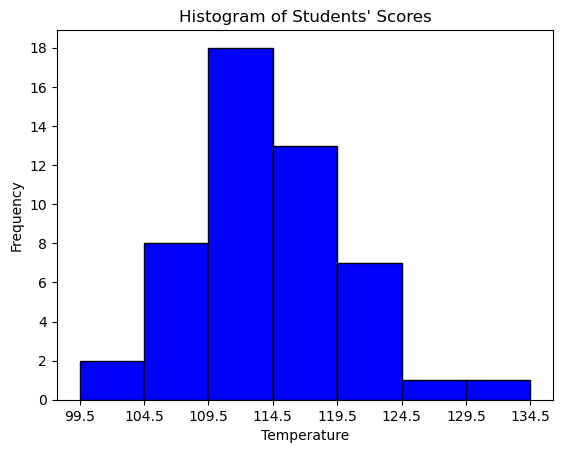

In [11]:
# x[0] the first item, lower bowndary
# + boundaries[-1][1] هنا بنضيف الحد العلوي من اخر عنصر 
boints = [x[0] for x in boundaries]+[boundaries[-1][1]]
plt.hist(data, bins=boints, edgecolor="black", color="blue")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Histogram of Students' Scores")
plt.xticks(boints)
plt.yticks(range(0, 20, 2))
plt.show()

## Relative Frequency

In [13]:
N = len(data)
rel_freq = [x/N for x in freq]
rel_freq

[0.04, 0.16, 0.36, 0.26, 0.14, 0.02, 0.02]

## Comulative frequency

In [15]:
cum_freq = []
sumf = 0
for i in freq:
    sumf += i
    cum_freq.append(sumf)
cum_freq

[2, 10, 28, 41, 48, 49, 50]

### Relative Comulative

In [18]:
cum_relfreq = []
rsumf = 0
for i in rel_freq:
    rsumf += i
    cum_relfreq.append(rsumf)
cum_relfreq

[0.04,
 0.2,
 0.56,
 0.8200000000000001,
 0.9600000000000001,
 0.9800000000000001,
 1.0]

## Ogive

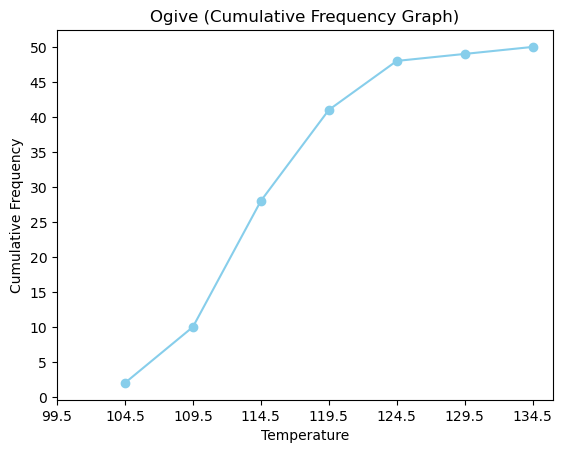

In [23]:
# b[1] بياخد الحد الأعلى من كل فئة
x = [b[1] for b in boundaries]
y = cum_freq
plt.plot(x, y, marker='o', color="skyblue")
# marker='o' يعني كل نقطة في الرسم تكون علامة دائرية.
plt.xlabel("Temperature")
plt.ylabel("Cumulative Frequency")
plt.title("Ogive (Cumulative Frequency Graph)")
plt.xticks(boints)
plt.yticks(range(0, N+1, 5))
# بيبدأ من 0 ويزود 5 كل مرة على محور y
plt.show()

## Polygon

In [20]:
midpoints = [(m + n) / 2 for m, n in classes]

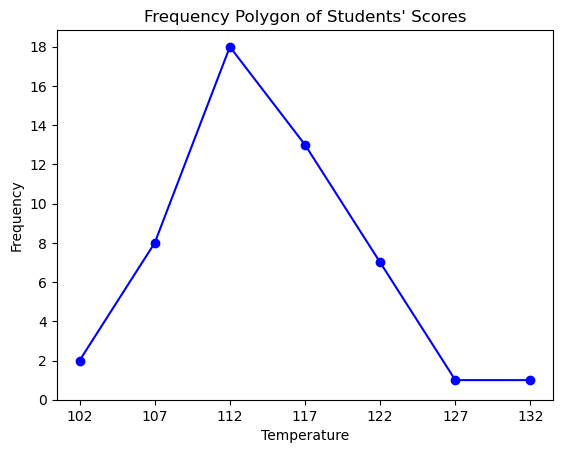

In [21]:
plt.plot(midpoints, freq, marker='o', color="blue")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Frequency Polygon of Students' Scores")
plt.xticks(midpoints)
plt.yticks(range(0, 20, 2))
plt.show()

## Print Grouped Frequency Distribution

In [22]:
df = pd.DataFrame({
    "Class Limits": classes,
    "Class Boundaries": boundaries,
    "Midpoint": midpoints,
    "Frequency": freq,
    "Relative Freq":rel_freq,
    "Cumulative Freq": cum_freq,
    "Cumulative relative Freq": cum_relfreq
})
print("Grouped Frequency Distribution:")
print(df)

Grouped Frequency Distribution:
  Class Limits Class Boundaries  Midpoint  Frequency  Relative Freq  \
0   (100, 104)    (99.5, 104.5)     102.0          2           0.04   
1   (105, 109)   (104.5, 109.5)     107.0          8           0.16   
2   (110, 114)   (109.5, 114.5)     112.0         18           0.36   
3   (115, 119)   (114.5, 119.5)     117.0         13           0.26   
4   (120, 124)   (119.5, 124.5)     122.0          7           0.14   
5   (125, 129)   (124.5, 129.5)     127.0          1           0.02   
6   (130, 134)   (129.5, 134.5)     132.0          1           0.02   

   Cumulative Freq  Cumulative relative Freq  
0                2                      0.04  
1               10                      0.20  
2               28                      0.56  
3               41                      0.82  
4               48                      0.96  
5               49                      0.98  
6               50                      1.00  
